# ggF Offline - Limit Plots

This notebook plots:

- 1D Brazil limit plots which show the observed and expected xsection limits as a function of $m_s$ for a given $m_{\phi}$, T and decay mode.  
- 2D limit plot of the observed excluded mu value as a function of $m_{\phi}$ (x-axis) and T (y-axis). 
- Summary plots: showing the $\mu=1$ exclusion limit for every value of $m_s$ and decay mode.

Using functions in `plot_utils.py`.

Use the Outline to navigate to the desired section.

In [1]:
%config InlineBackend.figure_format = 'retina'
import os
import matplotlib.pyplot as plt
import plot_utils as utils

plt.style.use('physics.mplstyle')

import mplhep as hep
hep.style.use("CMS")

In [2]:
# parameters
itag = '../WH_test/'

# outDir = '/home/submit/{}/public_html/SUEP/limits/debug/'.format(os.environ['USER'])
# outDirAN = '/home/submit/{}/SUEP/AN-22-133/images/offline/'.format(os.environ['USER'])
# outDirPaper = '/home/submit/{}/SUEP/EXO-23-002/'.format(os.environ['USER'])
# outDirSupp = '/home/submit/{}/SUEP/EXO-23-002/supplementary/'.format(os.environ['USER'])

saveToAN = False
saveToPaper = False

# if not os.path.isdir(outDir): os.mkdir(outDir)

## 2D Limits: $m_{\phi}$, T scan

In [59]:
import numpy as np
from matplotlib import ticker
import matplotlib.tri as tri
import pandas as pd
import math

def plot_mphi_by_T_limits(
        temp_by_mphi, ms, decay, 
        path='../', verbose=False, method='AsymptoticLimits', analysis='wh', 
        fig=None, ax=None, obs_marker='o', exp_alpha=1.0):
    """
    Make 1D Brazil plot for some choice of mPhi, temp, and decay, scanning over mS.
    """
    
    limits = utils.get_scan_limits(path=path, ms=ms, decay=decay, method=method, analysis=analysis)
    temp_over_mphi = np.array([l[0][1]/l[0][2] for l in limits])  
    limits = [l for l, tom in zip(limits, temp_over_mphi) if tom == temp_by_mphi]

    mphi = np.array([l[0][1] for l in limits])
    temp = np.array([l[0][2] for l in limits])
    xsec = np.array([l[0][4] for l in limits])

    _exp = np.array([l[1][1][2] for l in limits])
    _s1p = np.array([l[1][1][1] for l in limits]) 
    _s1m = np.array([l[1][1][3] for l in limits]) 
    _s2p = np.array([l[1][1][0] for l in limits]) 
    _s2m = np.array([l[1][1][4] for l in limits]) 
    _obs = np.array([l[1][1][5] for l in limits]) 
        
    # Define interpolation
    exp_limit = utils.log_interp1d(temp, _exp) 
    s1p_limit = utils.log_interp1d(temp, _s1p)
    s1m_limit = utils.log_interp1d(temp, _s1m)
    s2p_limit = utils.log_interp1d(temp, _s2p)
    s2m_limit = utils.log_interp1d(temp, _s2m)
    obs_limit = utils.log_interp1d(temp, _obs)
    th_limit =  utils.log_interp1d(temp, xsec)

    # Make 1D limit plot
    if ax is None:
        fig = plt.figure(figsize=(10,10))
        ax = fig.subplots()
        
    xvar = np.linspace(0,10,1000)
    
    #Plot expected limits including brazil bands
    ax.plot(xvar,th_limit(xvar),
         "--", ms=12, color='blue', label="$\sigma_{theory}$")
    ax.plot(xvar, exp_limit(xvar), ls="--", ms=12, color='black', label="Median expected")
    ax.fill_between(xvar, s2m_limit(xvar), s2p_limit(xvar), color="#FFCC01", alpha=exp_alpha, lw=0, label="Expected 95% CL")
    ax.fill_between(xvar, s1m_limit(xvar), s1p_limit(xvar), color="#00CC00", alpha=exp_alpha, lw=0, label="Expected 68% CL")

    # Plot observed limits
    ax.scatter(temp, _obs, marker=obs_marker, s=70, color='black', label="Observed") 
    #ax.plot(xvar,obs_limit(xvar),"-", ms=12, color='black')
    
    # Just to make everything look nice
    ax.set_ylabel(r"$\sigma$ (pb)")
    ax.set_xlabel(r"$T_D$ [GeV]") 
    ax.legend(loc="upper left", fontsize=20)

    _ = ax.text(
        0.65, 0.75, "$T_D/m_{{\phi}}$ = {}""\n""{}".format(temp_by_mphi,utils.decaysLabelsWithLineBreaks[decay]),
        fontsize=20, horizontalalignment='left', 
        verticalalignment='bottom', 
        transform=ax.transAxes,
    )
    
    hep.cms.label(data=True, lumi=utils.lumis['combined'], ax=ax) # To add CMS lumi scripts

    ax.grid(visible=True, which='major', color='grey', linestyle='--', alpha=0.3)
    ax.set_ylim(1e-6,9e7)
    ax.set_yscale("log")
    
    y_major = ticker.LogLocator(base = 10.0, numticks = 20)
    ax.yaxis.set_major_locator(y_major)
    y_minor = ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 100)
    ax.yaxis.set_minor_locator(y_minor)
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    if fig is not None:
        fig.tight_layout()
        fig.set_label("limits1D_mphi_by_T_{:.1f}_{}".format(temp_by_mphi, decay))
        return fig
    else:
        return ax



'path' must be a string, pathlib.Path, an object with 'read' and 'seek' methods, or a length-1 dict of {file_path: object_path}, not None
File doesn't exist None
'path' must be a string, pathlib.Path, an object with 'read' and 'seek' methods, or a length-1 dict of {file_path: object_path}, not None
File doesn't exist None
'path' must be a string, pathlib.Path, an object with 'read' and 'seek' methods, or a length-1 dict of {file_path: object_path}, not None
File doesn't exist None
'path' must be a string, pathlib.Path, an object with 'read' and 'seek' methods, or a length-1 dict of {file_path: object_path}, not None
File doesn't exist None
'path' must be a string, pathlib.Path, an object with 'read' and 'seek' methods, or a length-1 dict of {file_path: object_path}, not None
File doesn't exist None
'path' must be a string, pathlib.Path, an object with 'read' and 'seek' methods, or a length-1 dict of {file_path: object_path}, not None
File doesn't exist None
'path' must be a string, pat

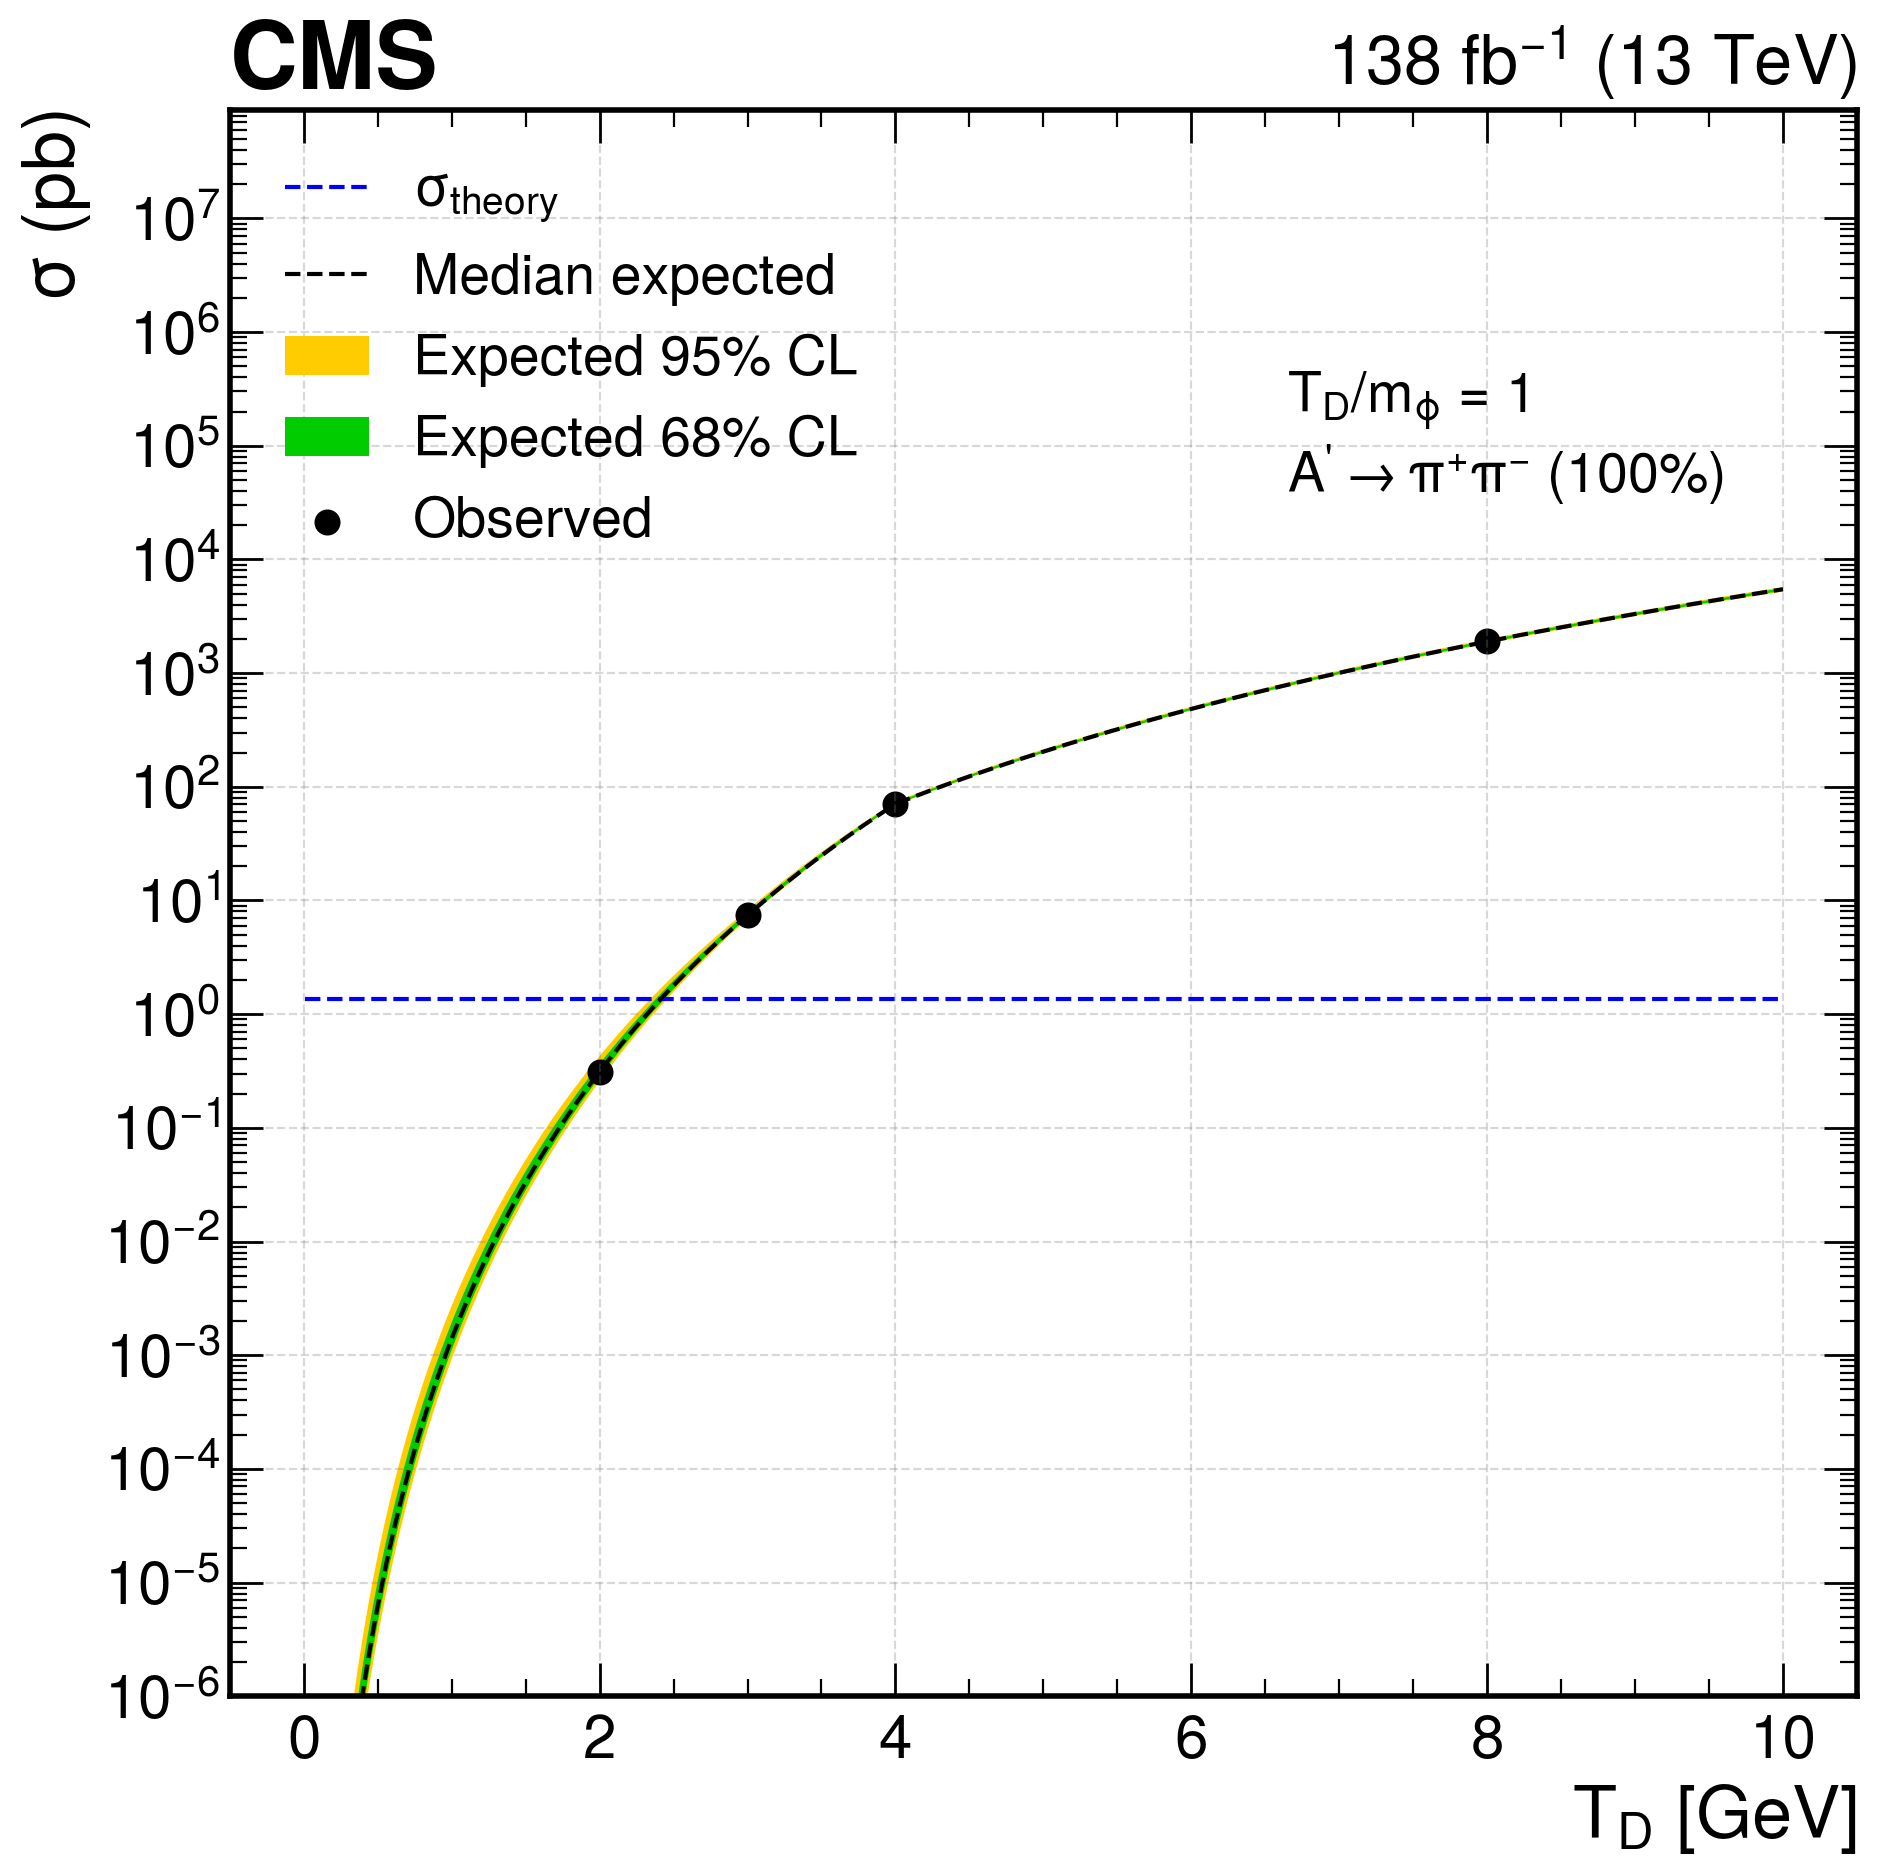

In [60]:
# example usage of the 2D limits function
fig = plot_mphi_by_T_limits(temp_by_mphi=1, ms=125, decay='generic', path=itag, method='AsymptoticLimits', analysis='wh')

In [ ]:
# return all combinations of (mS, decay)
combinations = utils.get_unique_combinations(['mphi', 'temp'])

for i, combination in enumerate(combinations):
    try:
        fig = utils.plot_mPhi_temp_limits(ms=combination[0], decay=combination[1], tricontour='log', path=itag)

        if combination[0] < 150:
            fig.axes[0].set_ylim(0, 2)
            fig.axes[0].set_xlim(right=4)
        elif combination[0] < 350:
            fig.axes[0].set_ylim(0, 5)
        elif combination[0] < 650:
            fig.axes[0].set_ylim(0, 10)
        elif combination[0] < 1050:
            fig.axes[0].set_ylim(5, 15)
        else:
            fig.axes[0].set_ylim(10, 35)

        utils.savefig(fig, outDir)
    except Exception as e:
        print("Combination failed", e)
    if saveToAN: utils.savefig(fig, outDirAN)
    if saveToPaper: utils.savefig(fig, outDirPaper)

    plt.close()

## Summary plots: $m_{\phi}$, T scan with $\mu$=1 lines for each $m_S$

In [ ]:
# example usage
fig = utils.plot_summary_limits_mPhi_temp(decay='generic', path='../approval_higherPrecision/', method='HybridNew', cmsLabel=False)
hep.cms.label(data=True, label="$\it{Supplementary}$ arXiv:2403.05311", italic=(False, False, False), lumi=utils.lumis['combined'], ax=fig.axes[0])
utils.savefig(fig, outDirPaper, "Figure_004")

fig = utils.plot_summary_limits_mPhi_temp(decay='hadronic', path='../approval_higherPrecision/', method='HybridNew', cmsLabel=False)
hep.cms.label(data=True, label="$\it{Supplementary}$ arXiv:2403.05311", italic=(False, False, False), lumi=utils.lumis['combined'], ax=fig.axes[0])
utils.savefig(fig, outDirSupp, "Figure-aux_003")

fig = utils.plot_summary_limits_mPhi_temp(decay='leptonic', path='../approval_higherPrecision/', method='HybridNew', cmsLabel=False)
hep.cms.label(data=True, label="$\it{Supplementary}$ arXiv:2403.05311", italic=(False, False, False), lumi=utils.lumis['combined'], ax=fig.axes[0])
utils.savefig(fig, outDirSupp, "Figure-aux_004")

In [ ]:
# over-engineered looping over the three decays :)
combinations = utils.get_unique_combinations(['ms','mphi','temp'])

for combination in combinations:
    try:
        fig = utils.plot_summary_limits_mPhi_temp(decay=combination[0], path=itag, method='HybridNew')    
    except Exception as e:
        print("Combination failed", e)
    utils.savefig(fig, outDir)
    if saveToAN: utils.savefig(fig, outDirAN)
    if saveToPaper: utils.savefig(fig, outDirPaper)

## 2D Limits: $m_S, T_D$ scan

In [ ]:
# example usage
fig = utils.plot_xsec_limits(mphi=3, decay='generic', path=itag)
utils.savefig(fig, outDir)

In [ ]:
# return all combinations of (mphi, decay)
combinations = utils.get_unique_combinations(['ms', 'temp'])

for i, combination in enumerate(combinations):
    try:
        fig = utils.plot_xsec_limits(mphi=combination[0], decay=combination[1], path=itag)
    except Exception as e:
        print("Combination failed", e)
    utils.savefig(fig, outDir)
    if saveToAN: utils.savefig(fig, outDirAN)
    if saveToPaper: utils.savefig(fig, outDirPaper)

    plt.close()

## Summary plots: $m_{S}$, T scan with $\mu$=1 lines for each $m_{\phi}$

In [ ]:
# example usage
fig = utils.plot_summary_limits_mS_temp(decay='generic', path=itag)
utils.savefig(fig, outDir)

In [ ]:
# over-engineered looping over the three decays :)
combinations = utils.get_unique_combinations(['ms','mphi','temp'])

for combination in combinations:
    try:
        fig = utils.plot_summary_limits_mS_temp(decay=combination[0], path=itag)
    except Exception as e:
        print("Combination failed", e)
    utils.savefig(fig, outDir)
    if saveToAN: utils.savefig(fig, outDirAN)
    if saveToPaper: utils.savefig(fig, outDirPaper)